# PatrolIQ - Notebook 2: Exploratory Data Analysis (EDA)

**Goal:** Understand crime patterns in the data before building any models -
which crimes are most common, where they happen, when they happen, and how
arrest/domestic status relate to other factors.

**Why EDA matters:** Clustering and PCA don't tell us *why* patterns exist,
they just group similar things together. EDA gives us the context to actually
interpret what the clusters mean later on.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../outputs/cleaned_crime_data.csv")
df.shape

(99939, 28)

## 1. Crime Type Distribution

Which crimes happen most often in our sample?

In [2]:
crime_counts = df["primary_type"].value_counts()
print("Number of distinct crime types:", df["primary_type"].nunique())
crime_counts.head(15)

Number of distinct crime types: 31


primary_type
THEFT                         21499
BATTERY                       18723
CRIMINAL DAMAGE               10949
ASSAULT                        9085
MOTOR VEHICLE THEFT            7862
OTHER OFFENSE                  6614
BURGLARY                       6460
DECEPTIVE PRACTICE             5382
NARCOTICS                      2697
CRIMINAL TRESPASS              2362
WEAPONS VIOLATION              2254
ROBBERY                        1924
CRIMINAL SEXUAL ASSAULT         710
OFFENSE INVOLVING CHILDREN      668
SEX OFFENSE                     610
Name: count, dtype: int64

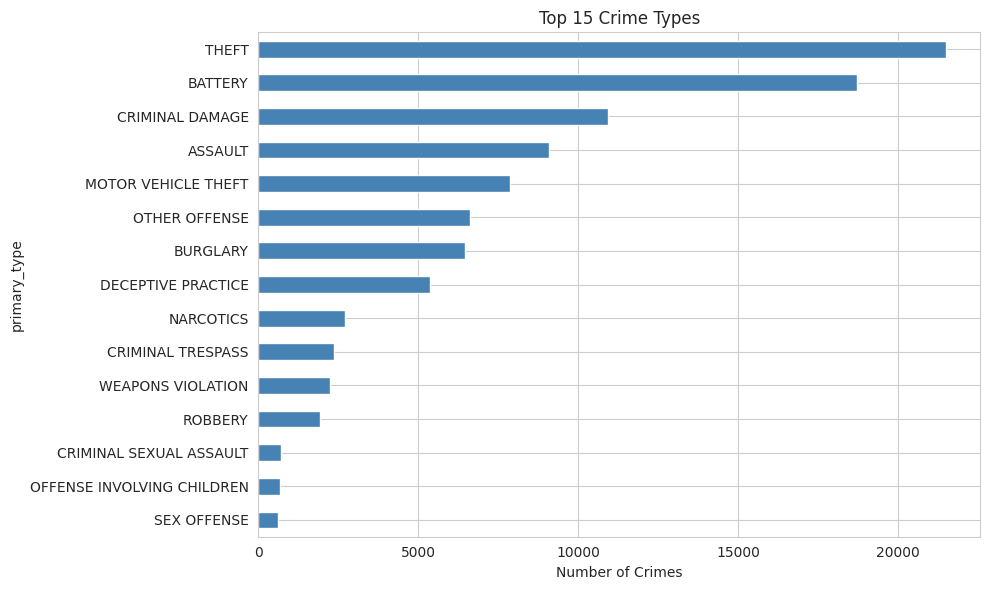

In [3]:
plt.figure(figsize=(10, 6))
crime_counts.head(15).plot(kind="barh", color="steelblue")
plt.xlabel("Number of Crimes")
plt.title("Top 15 Crime Types")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** THEFT, BATTERY, and CRIMINAL DAMAGE are the most common crime
types by far, together making up a large share of all records. This matches what
we'd expect for a big city - property crimes and assaults tend to be the most
frequent police reports.

## 2. Geographic Patterns

Where are crimes concentrated across the city?

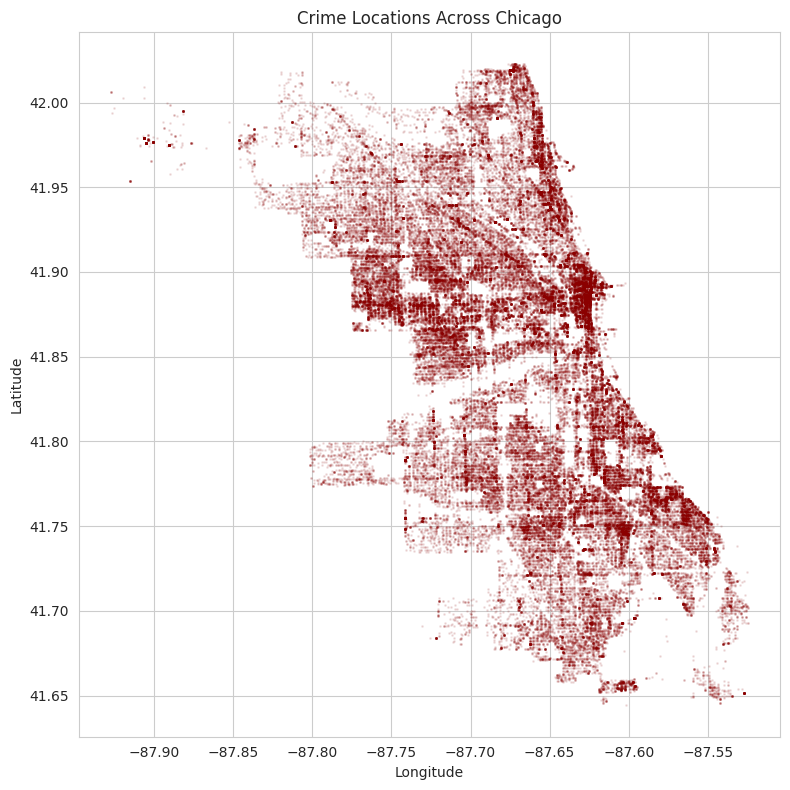

In [4]:
plt.figure(figsize=(8, 8))
plt.scatter(df["longitude"], df["latitude"], s=1, alpha=0.1, color="darkred")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Crime Locations Across Chicago")
plt.tight_layout()
plt.show()

**Observation:** Even without clustering yet, we can already see that crimes
are not evenly spread - some areas have a much higher density of points than others.
This gives us a visual preview of what our clustering algorithms should find later.

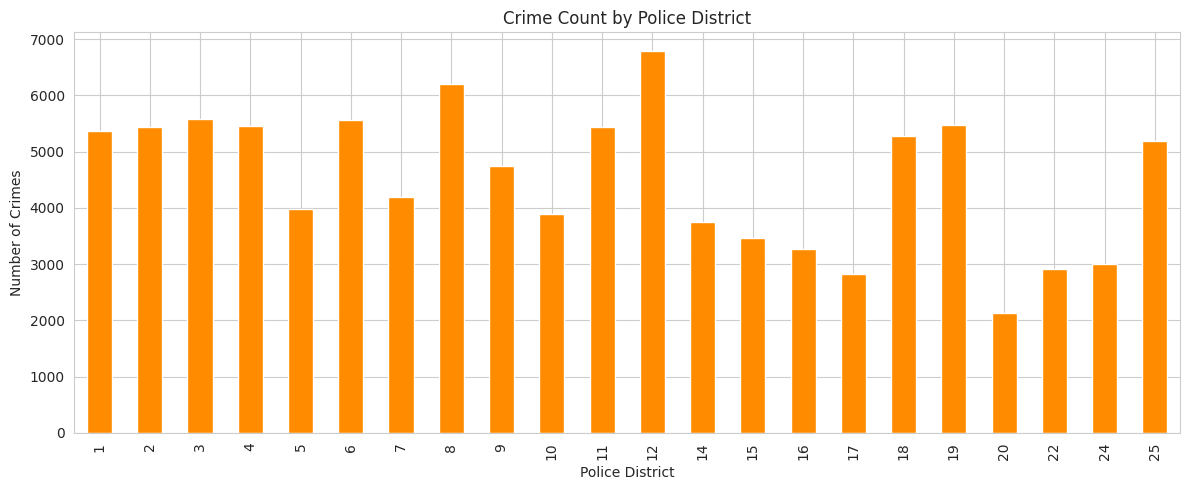

In [5]:
district_counts = df["district"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
district_counts.plot(kind="bar", color="darkorange")
plt.xlabel("Police District")
plt.ylabel("Number of Crimes")
plt.title("Crime Count by Police District")
plt.tight_layout()
plt.show()

## 3. Temporal Trends

When do crimes happen most - by hour, day, and month?

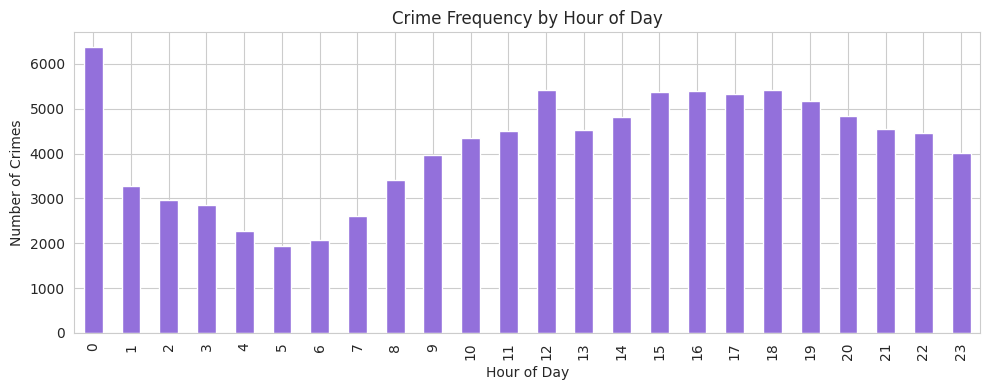

In [6]:
plt.figure(figsize=(10, 4))
df["hour"].value_counts().sort_index().plot(kind="bar", color="mediumpurple")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequency by Hour of Day")
plt.tight_layout()
plt.show()

**Observation:** Crime frequency is lowest in the very early morning hours
(around 4-6 AM) and rises through the day, peaking in the evening. This matches
common sense - fewer people are out and about late at night/early morning, though
the crimes that do happen then (like burglary) may be more serious.

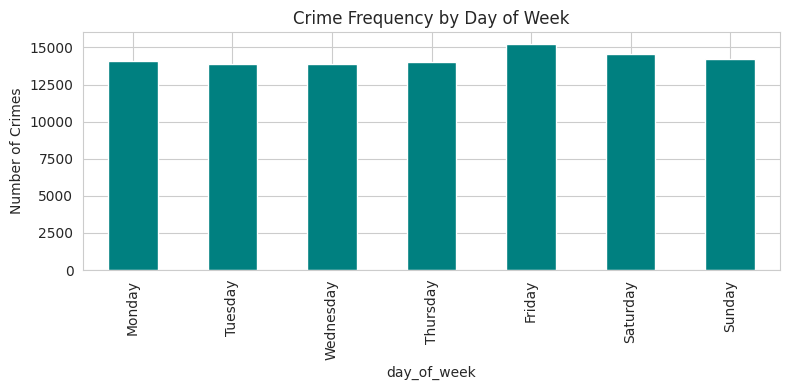

In [7]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(8, 4))
df["day_of_week"].value_counts().reindex(day_order).plot(kind="bar", color="teal")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequency by Day of Week")
plt.tight_layout()
plt.show()

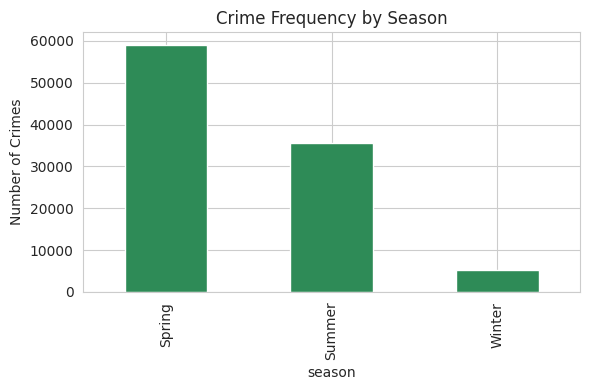

In [8]:
plt.figure(figsize=(6, 4))
df["season"].value_counts().plot(kind="bar", color="seagreen")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequency by Season")
plt.tight_layout()
plt.show()

**Observation:** Our dataset happens to span only a few months (Feb-July 2026,
since we sampled the *most recent* records), so the seasonal comparison here is
limited - a full year of data would give a more complete seasonal picture. This is
an honest limitation of using a recent-records sample instead of the full dataset.

## 4. Arrest Rate and Domestic Incident Analysis

In [9]:
print("Overall arrest rate:", round(df["arrest"].mean() * 100, 1), "%")
print("Arrest rate for domestic incidents:", round(df[df["domestic"] == True]["arrest"].mean() * 100, 1), "%")
print("Arrest rate for non-domestic incidents:", round(df[df["domestic"] == False]["arrest"].mean() * 100, 1), "%")

Overall arrest rate: 15.0 %
Arrest rate for domestic incidents: 15.7 %
Arrest rate for non-domestic incidents: 14.9 %


**Observation:** The arrest rate is quite similar for domestic (15.7%) and
non-domestic (14.9%) incidents in our sample - only a small difference. Overall,
only about 15% of reported crimes result in an arrest, which is a realistic and
important insight for the police department - it highlights that most crimes are
not immediately resolved with an arrest.

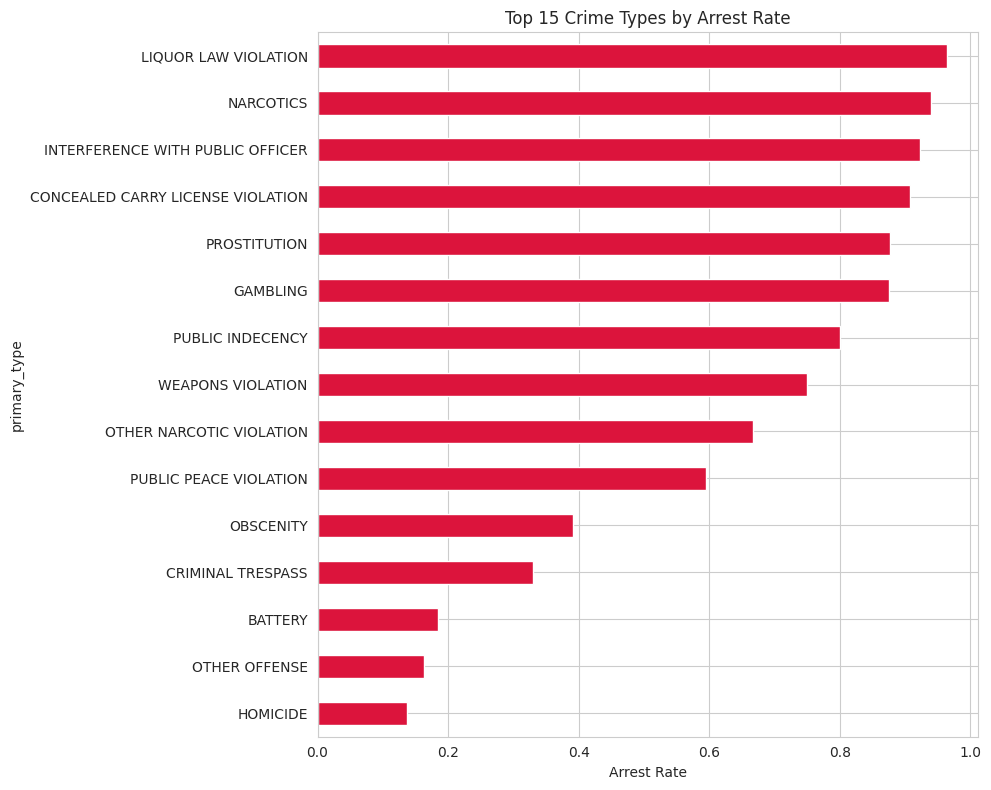

In [10]:
arrest_by_type = df.groupby("primary_type")["arrest"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
arrest_by_type.head(15).plot(kind="barh", color="crimson")
plt.xlabel("Arrest Rate")
plt.title("Top 15 Crime Types by Arrest Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Location Description Analysis

In [11]:
df["location_description"].value_counts().head(10)

location_description
STREET                                    28479
APARTMENT                                 19239
RESIDENCE                                 11649
SIDEWALK                                   5048
PARKING LOT / GARAGE (NON RESIDENTIAL)     3508
SMALL RETAIL STORE                         3346
DEPARTMENT STORE                           2115
ALLEY                                      2094
RESTAURANT                                 2080
OTHER (SPECIFY)                            1699
Name: count, dtype: int64

**Observation:** STREET, APARTMENT, and RESIDENCE are the most common
locations where crimes are reported, which makes sense since these are the places
people spend the most time.

## Summary of EDA Findings

- Theft, Battery, and Criminal Damage are the most frequent crime types.
- Crime is not evenly distributed geographically - some districts/areas are far more
  affected than others (this will be confirmed more precisely with clustering).
- Crime frequency is lowest in early morning hours and highest in the evening.
- Only about 15% of crimes result in an arrest, and this doesn't differ much between
  domestic and non-domestic incidents.
- STREET, APARTMENT, and RESIDENCE are the most common crime locations.

These findings guide our feature engineering and clustering approach in the next notebooks.